# Single Simulation Analysis

This notebook analyzes a single simulation output CSV from your ABM.

**Analyses Included:**
- Population dynamics (adults, larvae, pupae)
- Environmental correlations (temperature, precipitation, building density, population)
- Multi-variable impact assessment
- Stage duration estimation
- λ_max validation
- Suitability maps (KDE and rasterized tank load)
- Validation against GBIF/iNaturalist occurrences

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.stats import pearsonr, spearmanr
from scipy.signal import correlate, correlation_lags
from scipy.ndimage import uniform_filter1d
from sklearn.neighbors import KernelDensity
from scipy.interpolate import RegularGridInterpolator
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import rasterio
from rasterio.transform import from_origin
import os
import warnings
from collections import defaultdict

warnings.filterwarnings('ignore')

# ======================================================================
# CONFIGURATION - UPDATE THESE PATHS
# ======================================================================
INPUT_FILE = "/home/void/Documents/codes/monadvsim/results/merged_snapshots_20260831_054501.csv"
STUDY_AREA_FILE = "/home/void/Documents/codes/monadvsim/prepared_data/somali/somali.shp"
OUTPUT_DIR = "/mnt/monadworld/projects/phd/article_manuscripts/new/manuscript3/figs"
OCCURRENCE_FILE = "prepared_data/ethiopia_occurrence/merged_observations.csv"

TICKS_PER_DAY = 96
CHUNKSIZE = 100000
MAX_SPATIAL_POINTS_PER_TICK = 100000
STAGE_COLORS = {'ADULT': '#2E8B57', 'LARVA': '#4169E1', 'PUPA': '#FF8C00'}
KDE_BANDWIDTH_DEG = 0.002
KDE_GRID_RES = 200

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration ready.")

Configuration ready.


## 1. Data Loading

In [28]:
# ----------------------------------------------------------------------
# Load Study Area
# ----------------------------------------------------------------------
def load_study_area(filepath):
    if not os.path.exists(filepath):
        print(f"Study area file not found: {filepath}")
        return None
    study_area = gpd.read_file(filepath)
    if study_area.crs is None:
        study_area.crs = "EPSG:4326"
    elif study_area.crs.to_epsg() != 4326:
        study_area = study_area.to_crs("EPSG:4326")
    print(f"Loaded study area basemap: {filepath}")
    print(f"Bounds: {study_area.total_bounds}")
    return study_area

# ----------------------------------------------------------------------
# Load Occurrence Data
# ----------------------------------------------------------------------
def load_occurrences(filepath, study_area):
    if not filepath or not os.path.exists(filepath):
        print("No occurrence file provided")
        return None
    
    if filepath.endswith(('.shp', '.geojson')):
        occ = gpd.read_file(filepath).to_crs("EPSG:4326")
    else:
        occ_df = pd.read_csv(filepath, delimiter=",")
        if 'longitude' in occ_df.columns and 'latitude' in occ_df.columns:
            occ = gpd.GeoDataFrame(occ_df, 
                                   geometry=gpd.points_from_xy(occ_df.longitude, occ_df.latitude), 
                                   crs="EPSG:4326")
        else:
            print("Occurrence CSV must contain 'longitude' and 'latitude' columns.")
            return None
    
    original_count = len(occ)
    if study_area is not None:
        if occ.crs != study_area.crs:
            occ = occ.to_crs(study_area.crs)
        occ = gpd.sjoin(occ, study_area, how='inner', predicate='within')
        occ = occ.drop(columns='index_right')
        print(f"Clipped occurrence records from {original_count} to {len(occ)} (inside study area)")
    else:
        print(f"Loaded {original_count} occurrence records")
    return occ

# ----------------------------------------------------------------------
# Detect environment columns from CSV
# ----------------------------------------------------------------------
def detect_env_columns(filepath):
    chunk = pd.read_csv(filepath, nrows=5)
    all_cols = chunk.columns.tolist()
    
    print(f"Available columns in CSV: {all_cols}")
    
    env_vars = []
    
    # Look for temperature columns
    temp_cols = [c for c in all_cols if 't2m' in c.lower() or 'temp' in c.lower()]
    for col in temp_cols:
        try:
            sample = chunk[col].dropna()
            if not sample.empty:
                mean_val = sample.mean()
                if 250 < mean_val < 330:
                    env_vars.append((col, 'Temperature', '°C', 'K', lambda x: x - 273.15))
                    print(f"Detected temperature column: {col} (mean: {mean_val:.1f}K)")
                elif -50 < mean_val < 50:
                    env_vars.append((col, 'Temperature', '°C', '°C', lambda x: x))
                    print(f"Detected temperature column: {col} (mean: {mean_val:.1f}°C)")
        except Exception as e:
            print(f"Could not parse column {col}: {e}")
    
    # Look for precipitation columns
    precip_cols = [c for c in all_cols if 'tp' in c.lower() or 'precip' in c.lower() or 'rain' in c.lower()]
    for col in precip_cols:
        try:
            sample = chunk[col].dropna()
            if not sample.empty:
                mean_val = sample.mean()
                if mean_val < 0.1:
                    env_vars.append((col, 'Precipitation', 'mm', 'm', lambda x: x * 1000))
                    print(f"Detected precipitation column: {col} (mean: {mean_val:.4f}m)")
                else:
                    env_vars.append((col, 'Precipitation', 'mm', 'mm', lambda x: x))
                    print(f"Detected precipitation column: {col} (mean: {mean_val:.2f}mm)")
        except Exception as e:
            print(f"Could not parse column {col}: {e}")
    
    # Look for building density and population columns
    for col in all_cols:
        if 'building' in col.lower() or 'build' in col.lower():
            env_vars.append((col, 'BuildingDensity', 'fraction', 'fraction', lambda x: x))
            print(f"Detected building density column: {col}")
        if 'population' in col.lower() or 'pop' in col.lower():
            env_vars.append((col, 'Population', 'density', 'density', lambda x: x))
            print(f"Detected population column: {col}")
    
    return env_vars

# ----------------------------------------------------------------------
# Main
# ----------------------------------------------------------------------
study_area = load_study_area(STUDY_AREA_FILE)
occurrences = load_occurrences(OCCURRENCE_FILE, study_area)
ENV_VARS = detect_env_columns(INPUT_FILE)

if not ENV_VARS:
    print("WARNING: No environment columns detected! Using defaults.")
    ENV_VARS = [
        ('t2m', 'Temperature', '°C', 'K', lambda x: x - 273.15),
        ('tp', 'Precipitation', 'mm', 'm', lambda x: x * 1000),
        ('Buildings', 'BuildingDensity', 'fraction', 'fraction', lambda x: x),
        ('Population', 'Population', 'density', 'density', lambda x: x),
    ]

print(f"\nEnvironment variables: {[v[0] for v in ENV_VARS]}")
print("Data loading complete.")

Loaded study area basemap: /home/void/Documents/codes/monadvsim/prepared_data/somali/somali.shp
Bounds: [39.09111796  3.40667    47.98824    11.09707999]
Clipped occurrence records from 72 to 30 (inside study area)
Available columns in CSV: ['TickCount', 'AgentID', 'Layer', 'AgentType', 'X', 'Y', 'Alive', 'Age', 'Stage', 'Energy', 'Gravid', 'EggCount', 'LarvaCount', 'waterVolume', 'Resting', 'RestingDuration', 'TimeWithoutRest', 'Elevation', 'Buildings', 'Population', 't2m', 'tp']
Detected temperature column: t2m (mean: 27.1°C)
Detected precipitation column: tp (mean: 0.0356m)
Detected building density column: Buildings
Detected population column: Population

Environment variables: ['t2m', 'tp', 'Buildings', 'Population']
Data loading complete.


## 2. Aggregation

In [29]:
# Column definitions
living_base_cols = ['TickCount', 'Stage', 'X', 'Y', 'AgentID', 'Age', 'Energy', 'Gravid']
env_col_names = [v[0] for v in ENV_VARS]
living_columns = living_base_cols + env_col_names
inert_columns = ['TickCount', 'X', 'Y', 'EggCount', 'LarvaCount', 'waterVolume', 'AgentID']

print(f"Living columns: {living_columns}")
print(f"Inert columns: {inert_columns}")

# ----------------------------------------------------------------------
# Aggregation Functions
# ----------------------------------------------------------------------
def aggregate_daily_data(filepath, chunksize=CHUNKSIZE):
    daily_adults = defaultdict(int)
    daily_larvae = defaultdict(int)
    daily_pupae = defaultdict(int)
    daily_env_sum = {col: defaultdict(float) for col, _, _, _, _ in ENV_VARS}
    daily_env_cnt = {col: defaultdict(int) for col, _, _, _, _ in ENV_VARS}
    daily_tank_count = defaultdict(int)
    daily_water_sum = defaultdict(float)
    daily_water_cnt = defaultdict(int)
    daily_eggs_sum = defaultdict(int)
    daily_larva_sum = defaultdict(int)

    print("Starting chunked processing...")
    chunk_iter = pd.read_csv(filepath, chunksize=chunksize, low_memory=False)

    for i, chunk in enumerate(chunk_iter):
        if i % 10 == 0:
            print(f"Processing chunk {i}...")
        
        # Living agents
        living_mask = chunk['AgentType'] == 'LivingAgent'
        available_cols = [c for c in living_columns if c in chunk.columns]
        living_chunk = chunk.loc[living_mask, available_cols].copy()
        if not living_chunk.empty:
            living_chunk['Day'] = (living_chunk['TickCount'] // TICKS_PER_DAY).astype('int32')
            for day, grp in living_chunk.groupby('Day'):
                daily_adults[day] += (grp['Stage'] == 'ADULT').sum()
                daily_larvae[day] += (grp['Stage'] == 'LARVA').sum()
                daily_pupae[day] += (grp['Stage'] == 'PUPA').sum()
                for col, _, _, _, _ in ENV_VARS:
                    if col in grp.columns:
                        daily_env_sum[col][day] += grp[col].sum()
                        daily_env_cnt[col][day] += len(grp)

        # Inert agents
        inert_mask = chunk['AgentType'] == 'InertAgent'
        available_cols = [c for c in inert_columns if c in chunk.columns]
        inert_chunk = chunk.loc[inert_mask, available_cols].copy()
        if not inert_chunk.empty:
            inert_chunk['Day'] = (inert_chunk['TickCount'] // TICKS_PER_DAY).astype('int32')
            for day, grp in inert_chunk.groupby('Day'):
                daily_tank_count[day] += grp['AgentID'].nunique()
                if 'waterVolume' in grp.columns:
                    daily_water_sum[day] += grp['waterVolume'].sum()
                    daily_water_cnt[day] += len(grp)
                if 'EggCount' in grp.columns:
                    daily_eggs_sum[day] += grp['EggCount'].sum()
                if 'LarvaCount' in grp.columns:
                    daily_larva_sum[day] += grp['LarvaCount'].sum()

    all_days = sorted(set(daily_adults.keys()) | set(daily_larvae.keys()) |
                      set(daily_pupae.keys()) |
                      set().union(*[daily_env_sum[col].keys() for col in daily_env_sum]) |
                      set(daily_tank_count.keys()))

    daily_living_df = pd.DataFrame({'Day': all_days})
    daily_living_df['AdultCount'] = [daily_adults.get(d, 0) for d in all_days]
    daily_living_df['LarvaCount'] = [daily_larvae.get(d, 0) for d in all_days]
    daily_living_df['PupaCount'] = [daily_pupae.get(d, 0) for d in all_days]

    for col, disp, unit, _, convert in ENV_VARS:
        mean_col = f'Mean{disp}'
        raw_mean = [daily_env_sum[col].get(d, 0) / max(1, daily_env_cnt[col].get(d, 1)) for d in all_days]
        daily_living_df[mean_col] = convert(pd.Series(raw_mean)).round(2)

    daily_inert_df = pd.DataFrame({'Day': all_days})
    daily_inert_df['TankCount'] = [daily_tank_count.get(d, 0) for d in all_days]
    daily_inert_df['MeanWaterVolume'] = [
        daily_water_sum.get(d, 0) / max(1, daily_water_cnt.get(d, 1)) for d in all_days
    ]
    daily_inert_df['TotalEggs'] = [daily_eggs_sum.get(d, 0) for d in all_days]
    daily_inert_df['TotalLarvae'] = [daily_larva_sum.get(d, 0) for d in all_days]

    return daily_living_df, daily_inert_df

# ----------------------------------------------------------------------
# Run aggregation
# ----------------------------------------------------------------------
daily_living, daily_inert = aggregate_daily_data(INPUT_FILE)

print("\nDaily Living summary head:")
print(daily_living.head())
print("\nDaily Inert summary head:")
print(daily_inert.head())

Living columns: ['TickCount', 'Stage', 'X', 'Y', 'AgentID', 'Age', 'Energy', 'Gravid', 't2m', 'tp', 'Buildings', 'Population']
Inert columns: ['TickCount', 'X', 'Y', 'EggCount', 'LarvaCount', 'waterVolume', 'AgentID']
Starting chunked processing...
Processing chunk 0...

Daily Living summary head:
   Day  AdultCount  LarvaCount  PupaCount  MeanTemperature  MeanPrecipitation  \
0    1        5947        2483       1524            26.40              95.05   
1    2        5506        2468       1496            26.69              53.16   
2    3        5344        2437       1484            26.78               6.89   
3    4        5183        2413       1451            27.07               2.25   
4    5        5015        2381       1426            27.92              40.65   

   MeanBuildingDensity  MeanPopulation  
0                 0.01           65.76  
1                 0.01           65.84  
2                 0.01           65.13  
3                 0.01           65.19  
4        

## 3. Population Dynamics

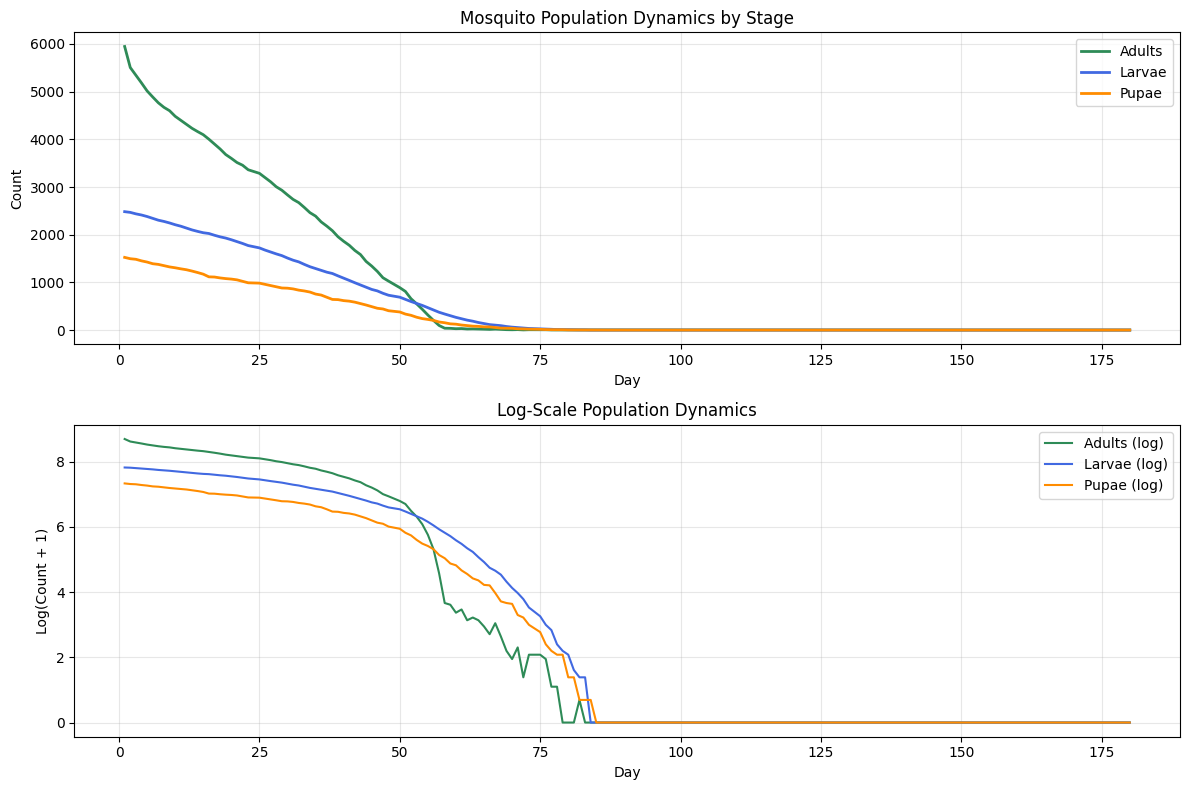

In [30]:
def plot_population_dynamics(df, output_dir):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Main population plot
    ax1.plot(df['Day'], df['AdultCount'], label='Adults', color=STAGE_COLORS['ADULT'], linewidth=2)
    ax1.plot(df['Day'], df['LarvaCount'], label='Larvae', color=STAGE_COLORS['LARVA'], linewidth=2)
    ax1.plot(df['Day'], df['PupaCount'], label='Pupae', color=STAGE_COLORS['PUPA'], linewidth=2)
    ax1.set_xlabel('Day')
    ax1.set_ylabel('Count')
    ax1.set_title('Mosquito Population Dynamics by Stage')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Log-scale plot to see dynamics better
    ax2.plot(df['Day'], np.log1p(df['AdultCount']), label='Adults (log)', color=STAGE_COLORS['ADULT'], linewidth=1.5)
    ax2.plot(df['Day'], np.log1p(df['LarvaCount']), label='Larvae (log)', color=STAGE_COLORS['LARVA'], linewidth=1.5)
    ax2.plot(df['Day'], np.log1p(df['PupaCount']), label='Pupae (log)', color=STAGE_COLORS['PUPA'], linewidth=1.5)
    ax2.set_xlabel('Day')
    ax2.set_ylabel('Log(Count + 1)')
    ax2.set_title('Log-Scale Population Dynamics')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/mosquito_dynamics.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_population_dynamics(daily_living, OUTPUT_DIR)

## 4. Environmental Impact Analysis

This section analyzes how different environmental variables (temperature, precipitation, building density, population density) affect mosquito populations.


ENVIRONMENTAL CORRELATION ANALYSIS

Temperature vs Adult Count:
  Pearson r = 0.572 (p=2.056e-16)
  Spearman r = 0.739 (p=3.569e-31)

Precipitation vs Adult Count:
  Pearson r = -0.053 (p=4.888e-01)
  Spearman r = 0.775 (p=5.819e-36)

BuildingDensity vs Adult Count:
  Pearson r = 0.836 (p=1.720e-46)
  Spearman r = 0.888 (p=1.029e-59)

Population vs Adult Count:
  Pearson r = 0.639 (p=3.223e-21)
  Spearman r = 0.888 (p=1.046e-59)


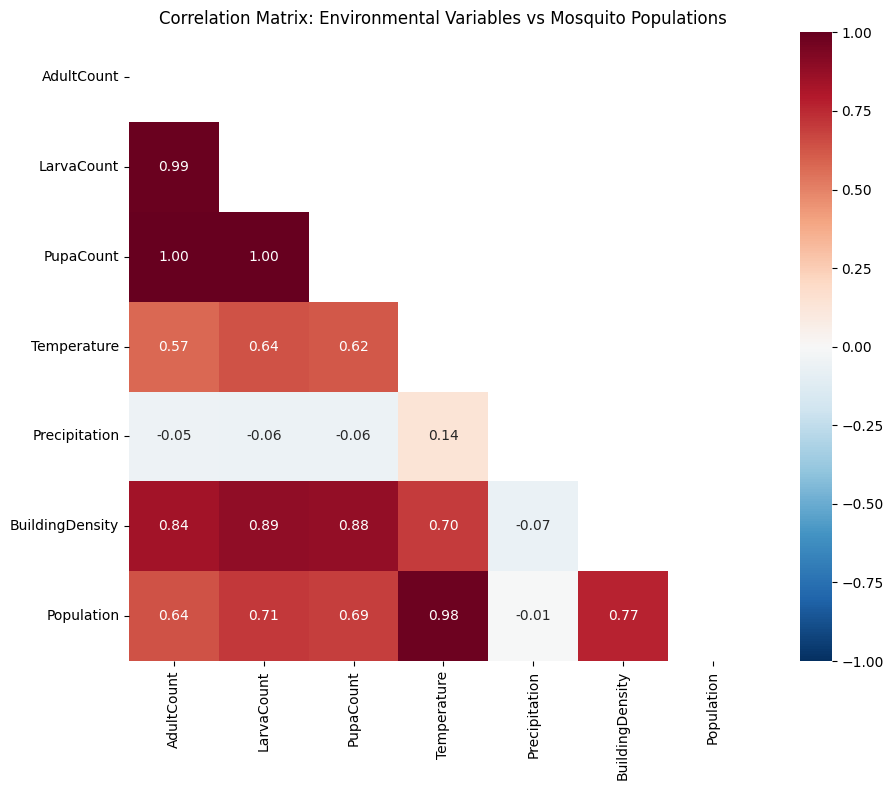

In [31]:
# ----------------------------------------------------------------------
# Environmental Correlation Analysis
# ----------------------------------------------------------------------

def analyze_environmental_correlations(df, env_vars, output_dir):
    """Analyze correlations between environmental variables and mosquito populations."""
    
    results = []
    
    # Identify variable columns
    var_columns = {}
    for col, disp, unit, _, _ in env_vars:
        mean_col = f'Mean{disp}'
        if mean_col in df.columns:
            var_columns[disp] = mean_col
    
    print("\n" + "="*70)
    print("ENVIRONMENTAL CORRELATION ANALYSIS")
    print("="*70)
    
    # Correlation with Adult count
    adult_series = df['AdultCount'].values
    
    for var_name, col in var_columns.items():
        var_series = df[col].values
        corr, p = pearsonr(adult_series, var_series)
        spearman_corr, spearman_p = spearmanr(adult_series, var_series)
        
        results.append({
            'variable': var_name,
            'pearson_r': corr,
            'pearson_p': p,
            'spearman_r': spearman_corr,
            'spearman_p': spearman_p,
            'significant': p < 0.05
        })
        
        print(f"\n{var_name} vs Adult Count:")
        print(f"  Pearson r = {corr:.3f} (p={p:.3e})")
        print(f"  Spearman r = {spearman_corr:.3f} (p={spearman_p:.3e})")
    
    # Create correlation matrix for all variables
    corr_vars = ['AdultCount', 'LarvaCount', 'PupaCount'] + list(var_columns.values())
    corr_df = df[corr_vars].copy()
    # Rename columns for better labels
    rename_map = {}
    for var_name, col in var_columns.items():
        rename_map[col] = var_name
    corr_df = corr_df.rename(columns=rename_map)
    
    # Correlation matrix plot
    plt.figure(figsize=(10, 8))
    corr_matrix = corr_df.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, 
                vmin=-1, vmax=1, fmt='.2f', square=True)
    plt.title('Correlation Matrix: Environmental Variables vs Mosquito Populations')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return pd.DataFrame(results)

correlation_results = analyze_environmental_correlations(daily_living, ENV_VARS, OUTPUT_DIR)
correlation_results.to_csv(f'{OUTPUT_DIR}/correlation_results.csv', index=False)

## 5. Temporal Lag Analysis

Temperature: Optimal lag = 10 days, correlation = 0.640
Precipitation: Optimal lag = 10 days, correlation = 0.057
BuildingDensity: Optimal lag = 10 days, correlation = 0.910
Population: Optimal lag = 10 days, correlation = 0.720


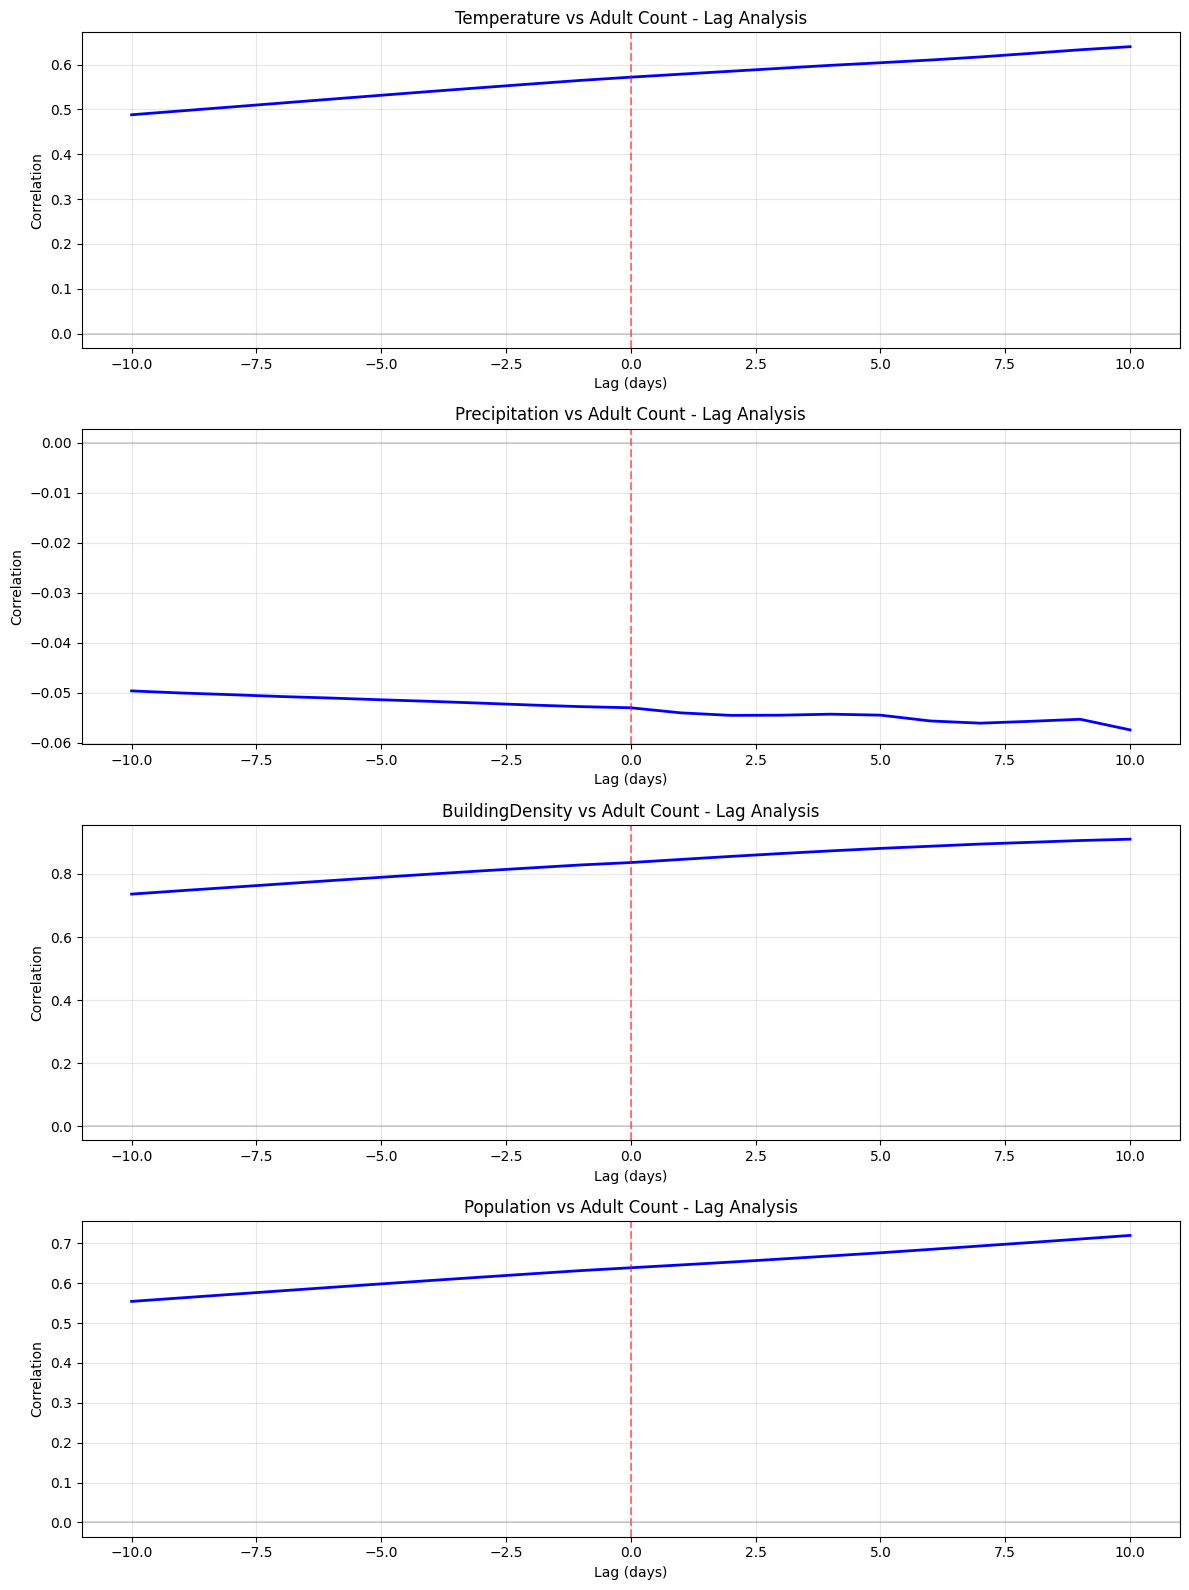

In [32]:
# ----------------------------------------------------------------------
# Temporal Lag Analysis
# ----------------------------------------------------------------------

def analyze_temporal_lags(df, env_vars, output_dir):
    """Analyze lagged correlations between environmental variables and populations."""
    
    # Identify variable columns
    var_columns = {}
    for col, disp, unit, _, _ in env_vars:
        mean_col = f'Mean{disp}'
        if mean_col in df.columns:
            var_columns[disp] = mean_col
    
    max_lag = 10  # days
    adult_series = df['AdultCount'].values
    
    fig, axes = plt.subplots(len(var_columns), 1, figsize=(12, 4*len(var_columns)))
    if len(var_columns) == 1:
        axes = [axes]
    
    lag_results = []
    
    for idx, (var_name, col) in enumerate(var_columns.items()):
        var_series = df[col].values
        lags = range(-max_lag, max_lag + 1)
        correlations = []
        
        for lag in lags:
            if lag < 0:
                # Environmental variable leads (past env affects current pop)
                corr = pearsonr(var_series[:lag], adult_series[-lag:])[0] if abs(lag) < len(adult_series) else 0
            elif lag > 0:
                # Environmental variable lags (current env affects future pop)
                corr = pearsonr(adult_series[:-lag], var_series[lag:])[0] if lag < len(adult_series) else 0
            else:
                corr = pearsonr(adult_series, var_series)[0]
            correlations.append(corr if not np.isnan(corr) else 0)
        
        axes[idx].plot(lags, correlations, 'b-', linewidth=2)
        axes[idx].axvline(0, color='r', linestyle='--', alpha=0.5)
        axes[idx].axhline(0, color='gray', linestyle='-', alpha=0.3)
        axes[idx].set_xlabel('Lag (days)')
        axes[idx].set_ylabel('Correlation')
        axes[idx].set_title(f'{var_name} vs Adult Count - Lag Analysis')
        axes[idx].grid(True, alpha=0.3)
        
        # Find optimal lag
        best_lag = lags[np.argmax(np.abs(correlations))]
        best_corr = max(np.abs(correlations))
        lag_results.append({
            'variable': var_name,
            'optimal_lag_days': best_lag,
            'max_abs_correlation': best_corr
        })
        print(f"{var_name}: Optimal lag = {best_lag} days, correlation = {best_corr:.3f}")
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/temporal_lag_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return pd.DataFrame(lag_results)

lag_results = analyze_temporal_lags(daily_living, ENV_VARS, OUTPUT_DIR)
lag_results.to_csv(f'{OUTPUT_DIR}/temporal_lag_results.csv', index=False)

## 6. Multi-Variable Impact (Random Forest)

Uses Random Forest to determine which environmental variables have the most impact on mosquito populations.


FEATURE IMPORTANCE (Random Forest)

Relative importance of environmental variables for predicting adult mosquito counts:
        feature  importance
BuildingDensity    0.703321
    Temperature    0.199242
  Precipitation    0.054710
     Population    0.042727


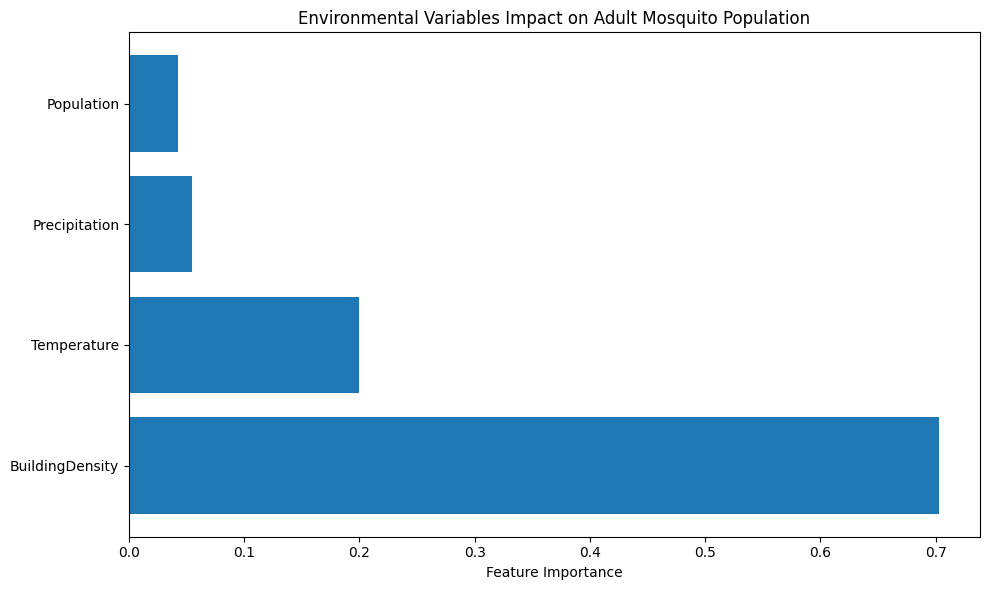

In [33]:
# ----------------------------------------------------------------------
# Random Forest Feature Importance
# ----------------------------------------------------------------------

def analyze_feature_importance(df, env_vars, output_dir):
    """Use Random Forest to determine feature importance for predicting mosquito populations."""
    
    # Identify variable columns
    var_columns = {}
    for col, disp, unit, _, _ in env_vars:
        mean_col = f'Mean{disp}'
        if mean_col in df.columns:
            var_columns[disp] = mean_col
    
    if not var_columns:
        print("No environmental variables found for feature importance analysis.")
        return
    
    # Prepare data
    X = df[list(var_columns.values())].copy()
    y = df['AdultCount'].values
    
    # Remove any rows with NaN
    valid_idx = ~X.isna().any(axis=1) & ~np.isnan(y)
    X = X[valid_idx]
    y = y[valid_idx]
    
    if len(X) < 10:
        print("Not enough valid data for feature importance analysis.")
        return
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_scaled, y)
    
    # Feature importance
    feature_names = list(var_columns.keys())
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n" + "="*70)
    print("FEATURE IMPORTANCE (Random Forest)")
    print("="*70)
    print("\nRelative importance of environmental variables for predicting adult mosquito counts:")
    print(importance_df.to_string(index=False))
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'], importance_df['importance'])
    plt.xlabel('Feature Importance')
    plt.title('Environmental Variables Impact on Adult Mosquito Population')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return importance_df

importance_results = analyze_feature_importance(daily_living, ENV_VARS, OUTPUT_DIR)
if importance_results is not None:
    importance_results.to_csv(f'{OUTPUT_DIR}/feature_importance.csv', index=False)

## 7. Species Parameters & Lifecycle

In [34]:
# Species parameters from your YAML
params_species = {
    "egg_dev_rho": 0.005000000000000001,
    "egg_dev_k": 39.20841161317061,
    "egg_dev_Delta": 1.9999999999999998,
    "egg_dev_lambda": -0.854916887158478,
    "larva_dev_a": 2.7054689312186438e-05,
    "larva_dev_Tmin": 5.123026541348266,
    "larva_dev_Tmax": 44.999999999835175,
    "larva_dev_m": 1.663077023745059,
    "pupa_dev_rho": 0.005115463305281753,
    "pupa_dev_k": 39.940257466039114,
    "pupa_dev_Delta": 1.9999999999999998,
    "pupa_dev_lambda": -0.9081661833839708,
    "egg_mort_b1": 3.572876,
    "egg_mort_b2": -0.323474,
    "egg_mort_b3": 0.004941,
    "larva_mort_b1": 1.9999999999999998,
    "larva_mort_b2": -0.7395036647759831,
    "larva_mort_b3": 0.017491023810106067,
    "pupa_mort_b1": 5.882576,
    "pupa_mort_b2": -0.578528,
    "pupa_mort_b3": 0.009458,
    "fecundity_rmax": 1.6021994175985133,
    "fecundity_Topt": 30.634033187663604,
    "fecundity_c": -0.0052723551194922445,
    "adult_mort_b1": -1.4775,
    "adult_mort_b2": -0.1377,
    "adult_mort_b3": 0.003908,
    "adult_mortality_per_day": 0.1198, 
    "sex_ratio": 0.5,
}

def egg_development_rate(T_C):
    rho = params_species['egg_dev_rho']
    k = params_species['egg_dev_k']
    Delta = params_species['egg_dev_Delta']
    lam = params_species['egg_dev_lambda']
    exp_arg = rho * k - (k - T_C) / Delta
    val = np.exp(rho * T_C - np.exp(exp_arg)) + lam
    return max(0, val)

def larva_development_rate(T_C):
    a = params_species['larva_dev_a']
    Tmin = params_species['larva_dev_Tmin']
    Tmax = params_species['larva_dev_Tmax']
    m = params_species['larva_dev_m']
    if T_C <= Tmin or T_C >= Tmax:
        return 0.0
    val = a * T_C * (T_C - Tmin) * (Tmax - T_C) ** (1.0/m)
    return max(0, val)

def pupa_development_rate(T_C):
    rho = params_species['pupa_dev_rho']
    k = params_species['pupa_dev_k']
    Delta = params_species['pupa_dev_Delta']
    lam = params_species['pupa_dev_lambda']
    exp_arg = rho * k - (k - T_C) / Delta
    val = np.exp(rho * T_C - np.exp(exp_arg)) + lam
    return max(0, val)

def egg_mortality_rate(T_C):
    return np.exp(params_species['egg_mort_b1'] + params_species['egg_mort_b2']*T_C + params_species['egg_mort_b3']*T_C**2)

def larva_mortality_rate(T_C):
    return np.exp(params_species['larva_mort_b1'] + params_species['larva_mort_b2']*T_C + params_species['larva_mort_b3']*T_C**2)

def pupa_mortality_rate(T_C):
    return np.exp(params_species['pupa_mort_b1'] + params_species['pupa_mort_b2']*T_C + params_species['pupa_mort_b3']*T_C**2)

def adult_mortality_rate(T_C):
    return np.exp(params_species['adult_mort_b1'] + params_species['adult_mort_b2']*T_C + params_species['adult_mort_b3']*T_C**2)

def fecundity_rate(T_C):
    rmax = params_species['fecundity_rmax']
    Topt = params_species['fecundity_Topt']
    c = params_species['fecundity_c']
    Sr = params_species['sex_ratio']
    val = np.exp(rmax + c * (Topt - T_C)**2)
    return max(0, val) * Sr

def theoretical_duration(rate_func, temp_celsius):
    rate = rate_func(temp_celsius)
    return 1.0 / rate if rate > 0 else np.inf

def get_temperature_column(df):
    for col in df.columns:
        if col.startswith('MeanTemperature'):
            return col
    return None

temp_col = get_temperature_column(daily_living)
print(f"Using temperature column: {temp_col}")

if temp_col is not None:
    mean_temp = daily_living[temp_col].mean()
    theo_larval = theoretical_duration(larva_development_rate, mean_temp)
    theo_pupal = theoretical_duration(pupa_development_rate, mean_temp)
    print(f"Theoretical larval duration at {mean_temp:.1f}°C: {theo_larval:.2f} days")
    print(f"Theoretical pupal duration at {mean_temp:.1f}°C: {theo_pupal:.2f} days")

Using temperature column: MeanTemperature
Theoretical larval duration at 12.9°C: 45.47 days
Theoretical pupal duration at 12.9°C: 6.24 days


## 8. Environment Plots

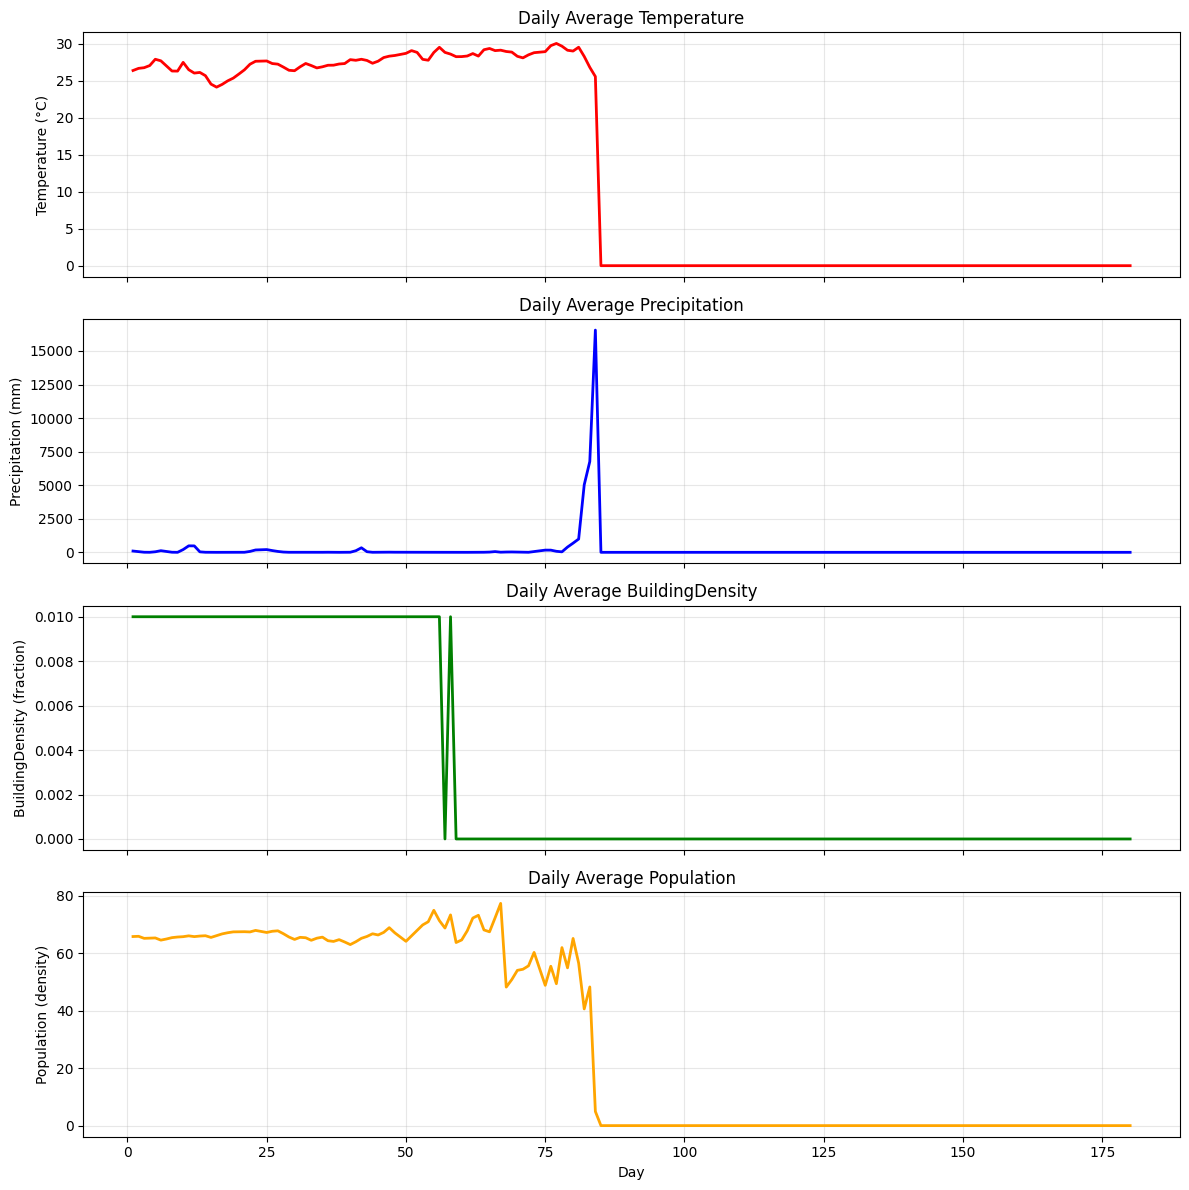

In [35]:
def plot_environment(df, env_vars, output_dir):
    if len(env_vars) == 0:
        print("No environment variables to plot.")
        return
    
    # Create a figure with subplots for each environmental variable
    n_vars = len(env_vars)
    fig, axes = plt.subplots(n_vars, 1, figsize=(12, 3*n_vars), sharex=True)
    if n_vars == 1:
        axes = [axes]
    
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    for i, (col, disp, unit, _, _) in enumerate(env_vars):
        mean_col = f'Mean{disp}'
        if mean_col not in df.columns:
            continue
        axes[i].plot(df['Day'], df[mean_col], color=colors[i % len(colors)], linewidth=2)
        axes[i].set_ylabel(f'{disp} ({unit})')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_title(f'Daily Average {disp}')
    
    axes[-1].set_xlabel('Day')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/environment.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_environment(daily_living, ENV_VARS, OUTPUT_DIR)

## 9. Tank Statistics

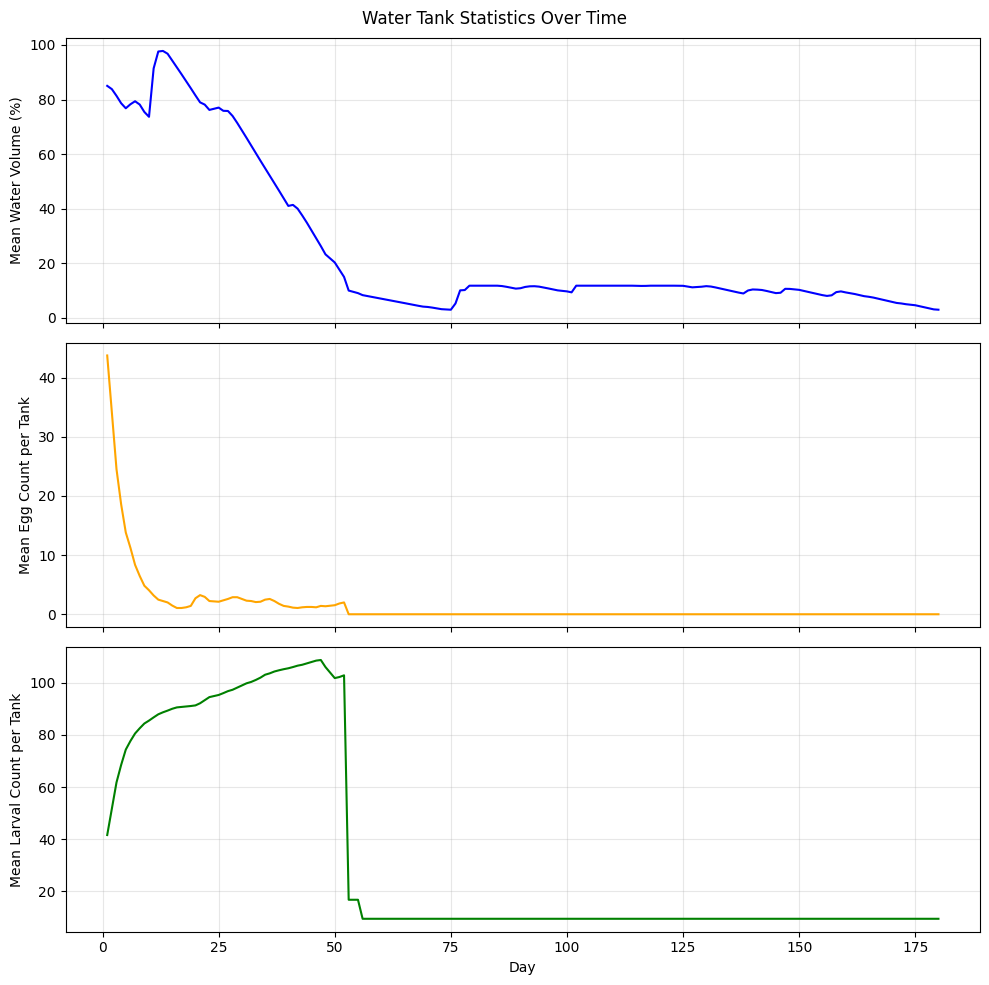

In [36]:
def plot_tank_stats(df, output_dir):
    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    axes[0].plot(df['Day'], df['MeanWaterVolume'], color='blue')
    axes[0].set_ylabel('Mean Water Volume (%)')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(df['Day'], df['TotalEggs'] / df['TankCount'].clip(lower=1), color='orange')
    axes[1].set_ylabel('Mean Egg Count per Tank')
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(df['Day'], df['TotalLarvae'] / df['TankCount'].clip(lower=1), color='green')
    axes[2].set_ylabel('Mean Larval Count per Tank')
    axes[2].set_xlabel('Day')
    axes[2].grid(True, alpha=0.3)
    plt.suptitle('Water Tank Statistics Over Time')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/tank_stats.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_tank_stats(daily_inert, OUTPUT_DIR)

## 10. KDE Suitability Maps

Two versions are created:
1. With occurrence points overlaid
2. Without occurrence points (clean map for publication)


KDE SUITABILITY MAPPING AND BOYCE INDEX VALIDATION
Adult points collected: 100000
KDE extent: x=[38.201406, 48.877952], y=[2.637629, 11.866121]
Raster shape: (200, 200)

----------------------------------------------------------------------
BOYCE INDEX VALIDATION
----------------------------------------------------------------------
Occurrence points used: 30
Top 20% suitability threshold: 0.0000
Proportion of occurrence points in top 20% suitability: 36.7%

Continuous Boyce Index = 0.381
Interpretation: Moderate predictive performance

Generating Boyce Index diagnostic plot...


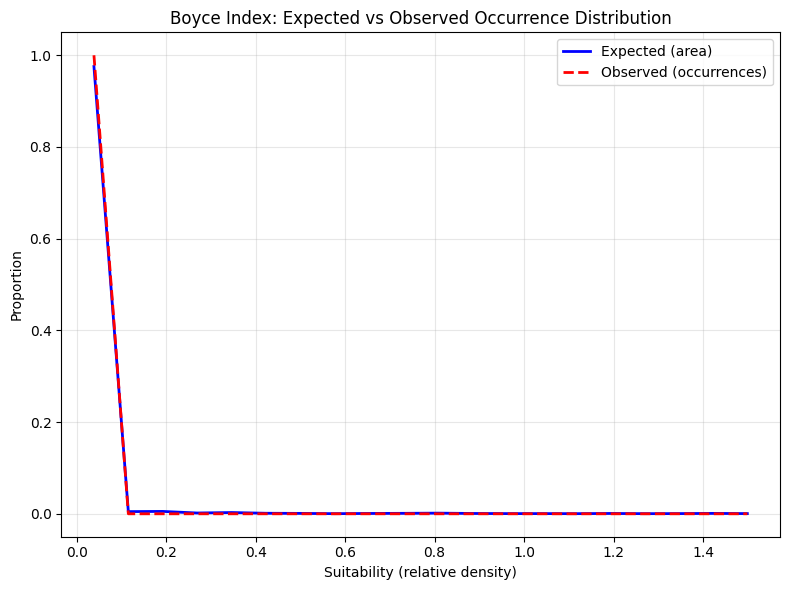

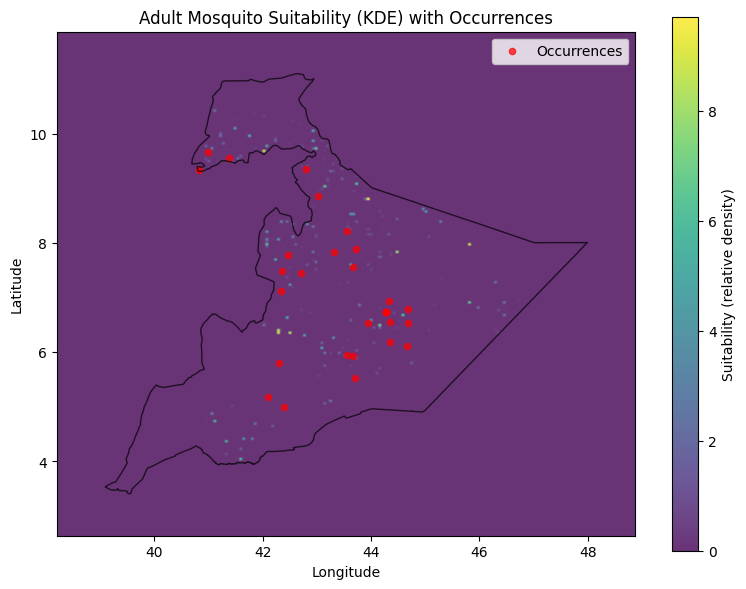

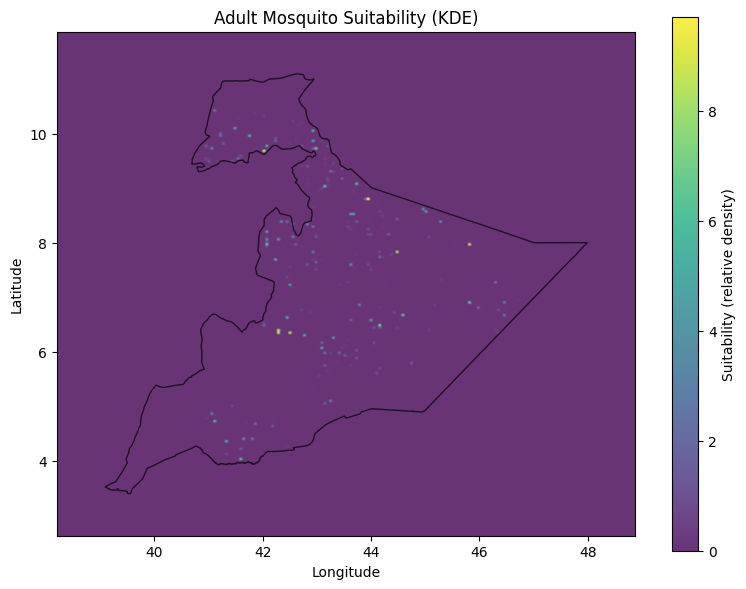


GeoTIFF saved to /mnt/monadworld/projects/phd/article_manuscripts/new/manuscript3/figs/adult_suitability.tif

VALIDATION SUMMARY
             Metric Value
  Occurrence Points    30
Top 20% Suitability 36.7%
        Boyce Index 0.381


In [37]:
## 10. KDE Suitability Maps with Boyce Index Validation

def accumulate_points(filepath, agent_type, stage=None, max_points=None):
    """
    Efficiently accumulate spatial points from chunks of the simulation output.
    Returns a DataFrame with X,Y coordinates.
    """
    usecols = ['TickCount', 'AgentType', 'X', 'Y']
    if stage is not None:
        usecols.append('Stage')
    
    all_points = []
    total = 0
    for chunk in pd.read_csv(filepath, chunksize=CHUNKSIZE, usecols=usecols, low_memory=False):
        mask = (chunk['AgentType'] == agent_type)
        if stage is not None:
            mask = mask & (chunk['Stage'] == stage)
        sub = chunk.loc[mask, ['X', 'Y']]
        if not sub.empty:
            all_points.append(sub)
            total += len(sub)
            if max_points and total >= max_points:
                break
    if not all_points:
        return pd.DataFrame()
    result = pd.concat(all_points, ignore_index=True)
    if max_points and len(result) > max_points:
        result = result.sample(n=max_points, random_state=42)
    return result

def create_kde_suitability(points, bandwidth_deg=KDE_BANDWIDTH_DEG, grid_res=KDE_GRID_RES):
    """
    Create a KDE raster from spatial points.
    Returns the grid and density raster.
    """
    if len(points) < 10:
        return None, None, None, None
    
    if study_area is not None:
        xmin, ymin, xmax, ymax = study_area.total_bounds
    else:
        xmin, xmax = points['X'].min(), points['X'].max()
        ymin, ymax = points['Y'].min(), points['Y'].max()
    
    # Add padding
    dx = (xmax - xmin) * 0.1
    dy = (ymax - ymin) * 0.1
    xmin -= dx
    xmax += dx
    ymin -= dy
    ymax += dy

    x = np.linspace(xmin, xmax, grid_res)
    y = np.linspace(ymin, ymax, grid_res)
    xx, yy = np.meshgrid(x, y)
    grid = np.vstack([xx.ravel(), yy.ravel()]).T
    
    kde = KernelDensity(bandwidth=bandwidth_deg, metric='euclidean')
    kde.fit(points[['X','Y']].values)
    log_dens = kde.score_samples(grid)
    dens = np.exp(log_dens).reshape(xx.shape)
    return xx, yy, dens, (xmin, xmax, ymin, ymax)

def continuous_boyce_index(suit_raster, x_grid, y_grid, occ_coords, n_bins=20):
    """
    Calculate the Continuous Boyce Index for model validation.
    
    The Boyce Index measures how well the model separates suitable
    from unsuitable habitat. Values range from -1 to 1, with positive
    values indicating good predictive performance.
    
    Parameters:
    -----------
    suit_raster : 2D array
        The suitability raster from the model
    x_grid : 1D array
        X coordinates for the raster
    y_grid : 1D array
        Y coordinates for the raster
    occ_coords : array-like
        Occurrence coordinates as [[x1,y1], [x2,y2], ...]
    n_bins : int
        Number of bins for the histogram
    
    Returns:
    --------
    float : The Boyce Index value
    """
    # Flatten the suitability raster and remove zeros
    suit_flat = suit_raster.ravel()
    suit_nonzero = suit_flat[suit_flat > 0]
    
    if len(suit_nonzero) == 0:
        return np.nan
    
    # Use percentiles to define the bin range (avoid extremes)
    suit_min, suit_max = np.percentile(suit_nonzero, [1, 99])
    
    # Handle edge cases
    if suit_min == suit_max:
        suit_min = suit_flat.min()
        suit_max = suit_flat.max()
    
    # Create bins
    bins = np.linspace(suit_min, suit_max, n_bins + 1)
    
    # Expected: proportion of area in each suitability bin
    area_counts, _ = np.histogram(suit_flat, bins=bins)
    expected = area_counts / area_counts.sum()
    
    # Observed: proportion of occurrences in each suitability bin
    interp = RegularGridInterpolator(
        (y_grid, x_grid), 
        suit_raster, 
        bounds_error=False, 
        fill_value=0
    )
    occ_vals = interp(occ_coords[:, [1, 0]])  # Note: (y, x) order
    obs_counts, _ = np.histogram(occ_vals, bins=bins)
    observed = obs_counts / obs_counts.sum()
    
    # Calculate Spearman correlation for bins with expected > 0
    valid = expected > 0
    if not valid.any():
        return np.nan
    
    return spearmanr(observed[valid], expected[valid])[0]

def plot_suitability_map(raster_data, extent, study_area, occurrences, 
                         title, output_path, cmap='viridis', show_occurrences=True):
    """
    Plot a suitability map with optional occurrence points overlay.
    """
    fig, ax = plt.subplots(figsize=(8,6))
    im = ax.imshow(raster_data, extent=extent, origin='upper', cmap=cmap, alpha=0.8)
    
    if study_area is not None:
        study_area.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.7)
    
    if show_occurrences and occurrences is not None:
        occurrences.plot(ax=ax, color='red', marker='o', markersize=20, 
                        alpha=0.7, label='Occurrences')
    
    plt.colorbar(im, label='Suitability (relative density)')
    plt.title(title)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    if show_occurrences:
        plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

# ======================================================================
# Main KDE and Validation Workflow
# ======================================================================

print("\n" + "="*70)
print("KDE SUITABILITY MAPPING AND BOYCE INDEX VALIDATION")
print("="*70)

# Collect adult points
adult_points = accumulate_points(
    INPUT_FILE, 'LivingAgent', stage='ADULT', 
    max_points=MAX_SPATIAL_POINTS_PER_TICK
)
print(f"Adult points collected: {len(adult_points)}")

# Create KDE
kde_result = create_kde_suitability(adult_points)

if kde_result[0] is not None:
    xx, yy, dens, extent = kde_result
    xmin, xmax, ymin, ymax = extent
    x_grid = xx[0, :]
    y_grid = yy[:, 0]
    
    print(f"KDE extent: x=[{xmin:.6f}, {xmax:.6f}], y=[{ymin:.6f}, {ymax:.6f}]")
    print(f"Raster shape: {dens.shape}")
    
    # ------------------------------------------------------------------
    # Boyce Index Validation (if occurrences are available)
    # ------------------------------------------------------------------
    if occurrences is not None and not occurrences.empty:
        print("\n" + "-"*70)
        print("BOYCE INDEX VALIDATION")
        print("-"*70)
        
        # Extract occurrence coordinates
        occ_coords = np.array([[geom.x, geom.y] for geom in occurrences.geometry])
        print(f"Occurrence points used: {len(occ_coords)}")
        
        # Interpolate suitability at occurrence points
        interp = RegularGridInterpolator(
            (y_grid, x_grid), 
            dens, 
            bounds_error=False, 
            fill_value=0
        )
        occ_dens = interp(occ_coords[:, [1, 0]])  # Note: interp expects (y, x)
        
        # Calculate proportion in top 20% suitability
        threshold = np.percentile(dens[dens > 0], 80)
        high_suit = occ_dens >= threshold
        pct_in_top20 = np.mean(high_suit) * 100
        
        print(f"Top 20% suitability threshold: {threshold:.4f}")
        print(f"Proportion of occurrence points in top 20% suitability: {pct_in_top20:.1f}%")
        
        # Calculate Continuous Boyce Index
        boyce = continuous_boyce_index(dens, x_grid, y_grid, occ_coords, n_bins=20)
        
        if not np.isnan(boyce):
            print(f"\nContinuous Boyce Index = {boyce:.3f}")
            
            # Interpret the Boyce Index
            if boyce > 0.75:
                interpretation = "Excellent predictive performance"
            elif boyce > 0.5:
                interpretation = "Good predictive performance"
            elif boyce > 0.3:
                interpretation = "Moderate predictive performance"
            else:
                interpretation = "Poor predictive performance"
            print(f"Interpretation: {interpretation}")
        else:
            print("Boyce Index could not be calculated (insufficient valid bins)")
        
        # Add a simple scatter plot of predicted vs expected
        print("\nGenerating Boyce Index diagnostic plot...")
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # Calculate expected and observed for bins
        suit_flat = dens.ravel()
        suit_nonzero = suit_flat[suit_flat > 0]
        suit_min, suit_max = np.percentile(suit_nonzero, [1, 99])
        bins = np.linspace(suit_min, suit_max, 21)
        
        area_counts, _ = np.histogram(suit_flat, bins=bins)
        expected = area_counts / area_counts.sum()
        
        occ_vals = interp(occ_coords[:, [1, 0]])
        obs_counts, _ = np.histogram(occ_vals, bins=bins)
        observed = obs_counts / obs_counts.sum()
        
        valid = expected > 0
        if valid.any():
            # Plot the P/E curve
            bin_centers = (bins[:-1] + bins[1:]) / 2
            ax.plot(bin_centers[valid], expected[valid], 'b-', label='Expected (area)', linewidth=2)
            ax.plot(bin_centers[valid], observed[valid], 'r--', label='Observed (occurrences)', linewidth=2)
            ax.set_xlabel('Suitability (relative density)')
            ax.set_ylabel('Proportion')
            ax.set_title('Boyce Index: Expected vs Observed Occurrence Distribution')
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'{OUTPUT_DIR}/boyce_index_diagnostic.png', dpi=300, bbox_inches='tight')
            plt.show()
    
    # ------------------------------------------------------------------
    # Generate Suitability Maps
    # ------------------------------------------------------------------
    # Map with occurrences (for validation)
    plot_suitability_map(
        dens, extent, study_area, occurrences,
        'Adult Mosquito Suitability (KDE) with Occurrences',
        f'{OUTPUT_DIR}/adult_suitability_with_occurrences.png',
        show_occurrences=True
    )
    
    # Map WITHOUT occurrences (clean map for publication)
    plot_suitability_map(
        dens, extent, study_area, occurrences,
        'Adult Mosquito Suitability (KDE)',
        f'{OUTPUT_DIR}/adult_suitability.png',
        show_occurrences=False
    )
    
    # ------------------------------------------------------------------
    # Export as GeoTIFF for GIS
    # ------------------------------------------------------------------
    from rasterio.transform import from_origin
    
    transform = from_origin(
        xmin, ymax,
        (xmax - xmin) / dens.shape[1],
        (ymax - ymin) / dens.shape[0]
    )
    
    with rasterio.open(
        f'{OUTPUT_DIR}/adult_suitability.tif', 'w', driver='GTiff',
        height=dens.shape[0], width=dens.shape[1],
        count=1, dtype=dens.dtype, crs='EPSG:4326',
        transform=transform
    ) as dst:
        dst.write(dens, 1)
    print(f"\nGeoTIFF saved to {OUTPUT_DIR}/adult_suitability.tif")
    
    # ------------------------------------------------------------------
    # Summary of validation results
    # ------------------------------------------------------------------
    if occurrences is not None and not occurrences.empty:
        print("\n" + "="*70)
        print("VALIDATION SUMMARY")
        print("="*70)
        summary_data = {
            'Metric': ['Occurrence Points', 'Top 20% Suitability', 'Boyce Index'],
            'Value': [
                len(occ_coords),
                f"{pct_in_top20:.1f}%",
                f"{boyce:.3f}" if not np.isnan(boyce) else "N/A"
            ]
        }
        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))

else:
    print("KDE creation failed - insufficient points")

## 11. Export Results

In [38]:
daily_summary = pd.merge(daily_living, daily_inert, on='Day', how='outer')
daily_summary.to_csv(f'{OUTPUT_DIR}/daily_summary.csv', index=False)
print(f"Daily summary saved to {OUTPUT_DIR}/daily_summary.csv")

# Sample of raw data
sample_df = pd.read_csv(INPUT_FILE, nrows=10000)
sample_df.to_csv(f'{OUTPUT_DIR}/living_sample.csv', index=False)
print(f"Sample data saved to {OUTPUT_DIR}/living_sample.csv")

# Also save a summary of the environment columns found
if ENV_VARS:
    env_summary = pd.DataFrame([{
        'column': v[0],
        'display_name': v[1],
        'unit': v[2],
        'data_type': v[3]
    } for v in ENV_VARS])
    env_summary.to_csv(f'{OUTPUT_DIR}/environment_columns.csv', index=False)

print("\nAnalysis complete!")

Daily summary saved to /mnt/monadworld/projects/phd/article_manuscripts/new/manuscript3/figs/daily_summary.csv
Sample data saved to /mnt/monadworld/projects/phd/article_manuscripts/new/manuscript3/figs/living_sample.csv

Analysis complete!
